In [1]:
print("a")

d

In [2]:
using Pkg

# name of the environment
Pkg.activate("catalyst_introduction")

# packages we will use in this tutorial
Pkg.add("Catalyst")
Pkg.add("OrdinaryDiffEqTsit5")
Pkg.add("Plots")
Pkg.add("Latexify")
Pkg.add("JumpProcesses")
Pkg.add("StochasticDiffEq")

  Activating new project at `c:\Users\wjh20\Documents\ProjectPaper\M5R\Interaction\TotalX\Network-models\catalyst_introduction`
  Installing known registries into `C:\Users\wjh20\.julia`
       Added `General` registry to C:\Users\wjh20\.julia\registries
    Updating registry at `C:\Users\wjh20\.julia\registries\General.toml`
   Resolving package versions...
   Installed MutableArithmetics ────────── v1.8.0
   Installed JpegTurbo_jll ─────────────── v3.2.0+1
   Installed Preferences ───────────────── v1.5.2
   Installed Accessors ─────────────────── v0.1.45
   Installed OffsetArrays ──────────────── v1.17.0
   Installed LoggingExtras ─────────────── v1.2.0
   Installed SciMLJacobianOperators ────── v0.1.18
   Installed TimerOutputs ──────────────── v1.2.0
   Installed FindFirstFunctions ────────── v3.2.1
   Installed Bijections ────────────────── v0.2.2
   Installed StaticArrays ──────────────── v1.9.19
   Installed SciMLLogging ──────────────── v2.1.0
   Installed DomainSets ─────────

In [3]:
using Catalyst, OrdinaryDiffEqTsit5, Plots, Latexify

In [4]:
rn = @reaction_network Repressilator begin
    hillr(P₃,α,K,n), ∅ --> m₁
    hillr(P₁,α,K,n), ∅ --> m₂
    hillr(P₂,α,K,n), ∅ --> m₃
    (δ,γ), m₁ <--> ∅
    (δ,γ), m₂ <--> ∅
    (δ,γ), m₃ <--> ∅
    β, m₁ --> m₁ + P₁
    β, m₂ --> m₂ + P₂
    β, m₃ --> m₃ + P₃
    μ, P₁ --> ∅
    μ, P₂ --> ∅
    μ, P₃ --> ∅
end

Model Repressilator:
Unknowns (6): see unknowns(Repressilator)
  m₁(t)
  m₂(t)
  m₃(t)
  P₁(t)
  ⋮
Parameters (7): see parameters(Repressilator)
  α
  K
  n
  δ
  ⋮

In [12]:
print(species(rn))
print(parameters(rn))
print(reactions(rn))

SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}[m₁(t), m₂(t), m₃(t), P₁(t), P₂(t), P₃(t)]SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{SymReal}[α, K, n, δ, γ, β, μ]Reaction[Catalyst.hillr(P₃(t), α, K, n), ∅ --> m₁, Catalyst.hillr(P₁(t), α, K, n), ∅ --> m₂, Catalyst.hillr(P₂(t), α, K, n), ∅ --> m₃, δ, m₁ --> ∅, γ, ∅ --> m₁, δ, m₂ --> ∅, γ, ∅ --> m₂, δ, m₃ --> ∅, γ, ∅ --> m₃, β, m₁ --> m₁ + P₁, β, m₂ --> m₂ + P₂, β, m₃ --> m₃ + P₃, μ, P₁ --> ∅, μ, P₂ --> ∅, μ, P₃ --> ∅]

In [14]:
Pkg.add("CairoMakie")

   Resolving package versions...
   Installed Unitful ───────────────────── v1.28.0
   Installed AxisArrays ────────────────── v0.4.8
   Installed ImageIO ───────────────────── v0.6.9
   Installed PNGFiles ──────────────────── v0.4.5
   Installed JpegTurbo ─────────────────── v0.1.6
   Installed TiffImages ────────────────── v0.11.9
   Installed AdaptivePredicates ────────── v1.2.0
   Installed Sixel ─────────────────────── v0.1.5
   Installed EarCut_jll ────────────────── v2.2.4+0
   Installed CEnum ─────────────────────── v0.5.0
   Installed OpenEXR ───────────────────── v0.3.3
   Installed SignedDistanceFields ──────── v0.4.1
   Installed Netpbm ────────────────────── v1.1.1
   Installed FilePaths ─────────────────── v0.9.0
   Installed ProgressMeter ─────────────── v1.11.0
   Installed BaseDirs ──────────────────── v1.4.0
   Installed FileIO ────────────────────── v1.20.0
   Installed RoundingEmulator ──────────── v0.2.1
   Installed TriplotBase ───────────────── v0.1.0
   Installe

In [16]:
Pkg.add("GraphMakie")
Pkg.add("NetworkLayout")

   Resolving package versions...
   Installed NetworkLayout ─── v0.4.10
   Installed PolynomialRoots ─ v1.1.0
   Installed GraphMakie ────── v0.6.6
    Updating `C:\Users\wjh20\Documents\ProjectPaper\M5R\Interaction\TotalX\Network-models\catalyst_introduction\Project.toml`
  [1ecd5474] + GraphMakie v0.6.6
    Updating `C:\Users\wjh20\Documents\ProjectPaper\M5R\Interaction\TotalX\Network-models\catalyst_introduction\Manifest.toml`
  [1ecd5474] + GraphMakie v0.6.6
  [46757867] + NetworkLayout v0.4.10
  [3a141323] + PolynomialRoots v1.1.0
Precompiling packages...
   1608.8 ms  ✓ PolynomialRoots
   2236.7 ms  ✓ NetworkLayout
   1553.2 ms  ✓ NetworkLayout → NetworkLayoutGraphsExt
   7274.5 ms  ✓ GraphMakie
  12649.7 ms  ✓ Catalyst → CatalystGraphMakieExtension
  5 dependencies successfully precompiled in 27 seconds. 570 already precompiled.
  479 dependencies precompiled but different versions are currently loaded (ADTypes, ADTypes → ADTypesChainRulesCoreExt, ADTypes → ADTypesConstructionBa

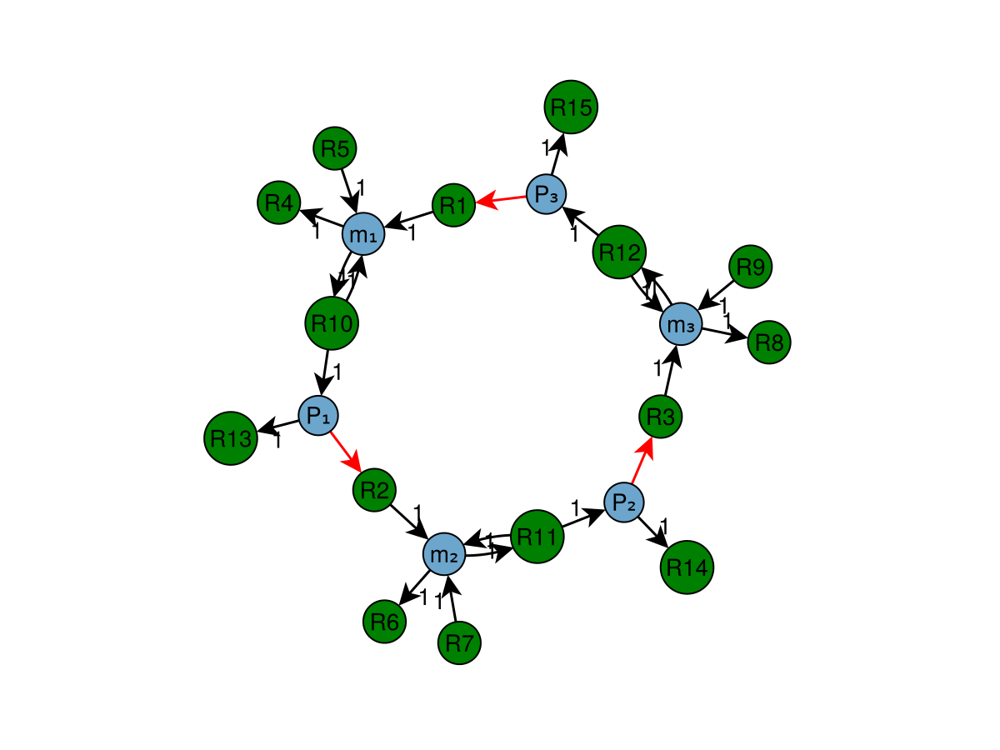

In [17]:
using Catalyst
import CairoMakie, GraphMakie, NetworkLayout
g = plot_network(rn)

In [19]:
odesys = ode_model(rn)

Model Repressilator:
Equations (6):
  6 standard: see equations(Repressilator)
Unknowns (6): see unknowns(Repressilator)
  m₁(t)
  m₂(t)
  m₃(t)
  P₁(t)
  ⋮
Parameters (7): see parameters(Repressilator)
  α
  K
  n
  δ
  ⋮

In [20]:
pmap  = (:α => .5, :K => 40, :n => 2, :δ => log(2)/120,
         :γ => 5e-3, :β => log(2)/6, :μ => log(2)/60)
u₀map = [:m₁ => 0., :m₂ => 0., :m₃ => 0., :P₁ => 20., :P₂ => 0., :P₃ => 0.]

6-element Vector{Pair{Symbol, Float64}}:
 :m₁ => 0.0
 :m₂ => 0.0
 :m₃ => 0.0
 :P₁ => 20.0
 :P₂ => 0.0
 :P₃ => 0.0

In [21]:
# time interval to solve on
tspan = (0., 10000.)

# create the ODEProblem we want to solve
oprob = ODEProblem(rn, u₀map, tspan, pmap)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Initialization status: FULLY_DETERMINED
Non-trivial mass matrix: false
timespan: (0.0, 10000.0)
u0: 6-element Vector{Float64}:
  0.0
  0.0
  0.0
 20.0
  0.0
  0.0

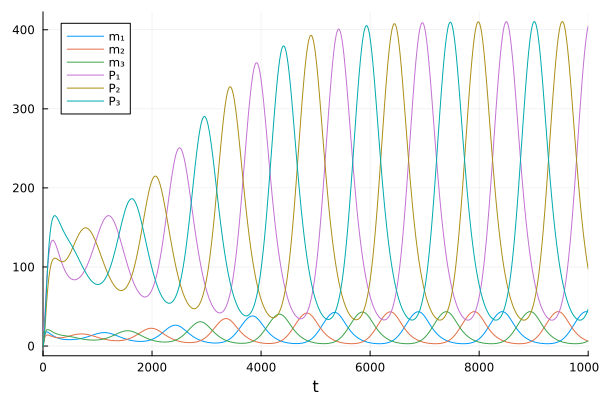

In [22]:
sol = solve(oprob, Tsit5(), saveat=10.0)
plot(sol)

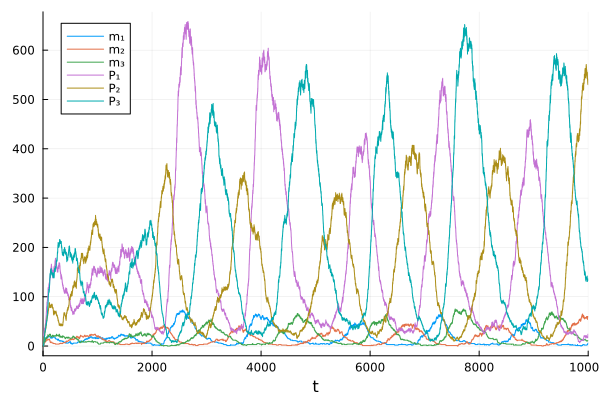

In [23]:
# imports the JumpProcesses packages
using JumpProcesses

# redefine the initial condition to be integer valued
u₀map = [:m₁ => 0, :m₂ => 0, :m₃ => 0, :P₁ => 20, :P₂ => 0, :P₃ => 0]

# now, we create a JumpProblem, and let a solver be chosen for us automatically
# in this case Gillespie's Direct Method will be selected
jprob = JumpProblem(rn, u₀map, tspan, pmap)

# now, let's solve and plot the jump process:
sol = solve(jprob)
plot(sol)

In [26]:
sol.u

133961-element Vector{Vector{Int64}}:
 [0, 0, 0, 20, 0, 0]
 [0, 1, 0, 20, 0, 0]
 [1, 1, 0, 20, 0, 0]
 [1, 1, 0, 21, 0, 0]
 [1, 1, 0, 21, 1, 0]
 [1, 1, 1, 21, 1, 0]
 [1, 1, 2, 21, 1, 0]
 [1, 1, 2, 21, 1, 1]
 [1, 2, 2, 21, 1, 1]
 [2, 2, 2, 21, 1, 1]
 ⋮
 [6, 59, 11, 23, 536, 133]
 [6, 59, 11, 23, 536, 134]
 [6, 59, 11, 23, 537, 134]
 [6, 59, 11, 23, 537, 135]
 [6, 59, 11, 23, 538, 135]
 [6, 59, 11, 23, 539, 135]
 [6, 59, 11, 23, 539, 136]
 [6, 59, 11, 23, 538, 136]
 [6, 59, 11, 23, 538, 136]